# Aula 7: Estatística descritiva de dados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/aula_07/estatística_descritiva.ipynb)

- **Professor:** Gustavo Sousa Cardoso
  - al.gustavo.cardoso@impatech.org.br

- **Monitores:**
  - Bianca Zavadisk
    - al.bianca.abreu@impatech.edu.br
  - Bruno Paula
    - al.bruno.paula@impatech.edu.br
  - Pedro Alberti
    - al.pedro.alberti@impatech.edu.br
  - Cristiane Sampaio
    - al.cristiane.sampaio@impatech.edu.br

- **Desenvolvedores:** 
  - Gustavo Sousa Cardoso
    - al.gustavo.cardoso@impatech.org.br
---

## Sobre este projeto

Essa aula vai ilustrar um pipeline de análise exploratória de dados com o uso
de estatística descritiva a partir da base **Diabetes Health Indicators Dataset**.

---

## 0. Setup — importar as bibliotecas

Será usado matplotlib, pandas 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)   # não truncar colunas ao imprimir
pd.set_option("display.float_format", "{:.2f}".format)  # 2 casas decimais

---

## 1. Baixar os dados

Baixe os dados no site do Kaggle em https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset e direcione o caminho do arquivo.


In [3]:
CAMINHO_CSV = "diabetes_dataset.csv"

---

## 2. Carregar e conhecer os dados

Após usar a ferramenta para carregar os dados, é uma boa prática ver o esquema da tabela em questão, em pandas isso pode ser acessado usando o info()

In [4]:
df = pd.read_csv(CAMINHO_CSV)
print("Formato (linhas, colunas):", df.shape)

Formato (linhas, colunas): (100000, 31)


Esses dados são bem limpos, como dito no Kaggle esses dados foram gerados por distribuições. Sendo dados sintéticos, eles não colaboram muito do ponto de vista científico, mas tem valor de ilustração por serem dados limpos e já preparados para esse propósito.

In [5]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.70,7.90,7.90,0,0,0,30.50,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.60,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.70,6.50,8.70,0,0,0,23.10,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.00,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.40,10.00,8.10,1,0,0,22.20,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.70,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.40,6.60,5.20,0,0,0,26.80,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.20,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.20,7.40,5.00,0,0,0,21.20,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.50,Type 2,1


Vamos ver as estatísticas descritivas das colunas numéricas utilizando o método `describe()` no nosso dataframe:

#### Variáveis

Antes de tocar no código, é importante entender **o que cada tipo de coluna representa**, porque isso determina *qual* estatística faz sentido calcular.

| Grupo | Colunas | Natureza |
|---|---|---|
| **Demografia** | `age`, `gender`, `ethnicity`, `education_level`, `income_level`, `employment_status` | Numérica (idade) + categóricas |
| **Estilo de vida** | `smoking_status`, `alcohol_consumption_per_week`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day` | Mistas |
| **Histórico clínico** | `family_history_diabetes`, `hypertension_history`, `cardiovascular_history` | Binárias (0/1) |
| **Medidas físicas** | `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate` | Numéricas contínuas |
| **Exames laboratoriais** | `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`, `glucose_fasting`, `glucose_postprandial`, `insulin_level`, `hba1c` | Numéricas contínuas |
| **Alvo (target)** | `diabetes_risk_score`, `diabetes_stage`, `diagnosed_diabetes` | Score contínuo, estágio categórico, diagnóstico binário |

---

## 3. Limpeza e preparação

Antes de analisarmos, é importante você verificar dois pontos:
1. Existem valores nulos ou impossíveis ( valores que 'não fazem sentido' )?
2. _Extra_: O que poderíamos fazer para "substituir" esses valores nulos? Faz sentido trocarmos esses valores por outra coisa? Podemos ignorar os dados com esses valores nulos? 


Sobre o segundo ponto. Veremos uma abordagem estatística para este problema nas próximas 2 aulas.


In [6]:
df.info()                      # tipos, contagem de não-nulos, uso de memória
df.dtypes.value_counts()       # quantas colunas de cada tipo
df.isnull().sum()              # contagem de nulos por coluna
df.isnull().mean() * 100       # % de nulos por coluna
df.duplicated().sum()          # linhas totalmente duplicadas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

0

Separação em colunas numéricas e categóricas

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Flags binárias disfarçadas de inteiro — tratar à parte
bin_cols = ["family_history_diabetes", "hypertension_history",
            "cardiovascular_history", "diagnosed_diabetes"]

# Numéricas "de verdade" (contínuas/discretas), sem as flags
num_real = [c for c in num_cols if c not in bin_cols]

print("Numéricas:", len(num_cols), "| Categóricas:", len(cat_cols))

Numéricas: 24 | Categóricas: 7


---

## 4. Estatísticas descritivas básicas

In [8]:
df[num_real].describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50.12,2.00,118.91,5.99,7.00,6.00,25.61,0.86,115.80,75.23,69.63,185.98,54.04,103.00,121.46,111.12,160.04,9.06,6.52,30.22
std,15.60,1.42,84.41,1.78,1.09,2.47,3.59,0.05,14.28,8.20,8.37,32.01,10.27,33.39,43.37,13.60,30.94,4.95,0.81,9.06
min,18.00,0.00,0.00,0.00,3.00,0.50,15.00,0.67,90.00,50.00,40.00,100.00,20.00,50.00,30.00,60.00,70.00,2.00,4.00,2.70
25%,39.00,1.00,57.00,4.80,6.30,4.30,23.20,0.82,106.00,70.00,64.00,164.00,47.00,78.00,91.00,102.00,139.00,5.09,5.97,23.80
50%,50.00,2.00,100.00,6.00,7.00,6.00,25.60,0.86,116.00,75.00,70.00,186.00,54.00,102.00,121.00,111.00,160.00,8.79,6.52,29.00
75%,61.00,3.00,160.00,7.20,7.70,7.70,28.00,0.89,125.00,81.00,75.00,208.00,61.00,126.00,151.00,120.00,181.00,12.45,7.07,35.60
max,90.00,10.00,833.00,10.00,10.00,16.80,39.20,1.06,179.00,110.00,105.00,318.00,98.00,263.00,344.00,172.00,287.00,32.22,9.80,67.20


In [9]:
central = pd.DataFrame({
    "media":    df[num_real].mean(),
    "mediana":  df[num_real].median(),
    "moda":     df[num_real].mode().iloc[0],
})
central

,media,mediana,moda
age,50.12,50.00,52.00
alcohol_consumption_per_week,2.00,2.00,2.00
physical_activity_minutes_per_week,118.91,100.00,59.00
diet_score,5.99,6.00,5.70
sleep_hours_per_day,7.00,7.00,7.00
screen_time_hours_per_day,6.00,6.00,5.80
bmi,25.61,25.60,25.40
waist_to_hip_ratio,0.86,0.86,0.86
systolic_bp,115.80,116.00,90.00
diastolic_bp,75.23,75.00,75.00


In [10]:
df[cat_cols].describe()   # count, unique, top (moda), freq

# Distribuição de cada categórica
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())                 # contagem absoluta
    print(df[col].value_counts(normalize=True))


=== gender ===
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64
gender
Female   0.50
Male     0.48
Other    0.02
Name: proportion, dtype: float64

=== ethnicity ===
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64
ethnicity
White      0.45
Hispanic   0.20
Black      0.18
Asian      0.12
Other      0.05
Name: proportion, dtype: float64

=== education_level ===
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64
education_level
Highschool     0.45
Graduate       0.35
Postgraduate   0.15
No formal      0.05
Name: proportion, dtype: float64

=== income_level ===
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64
income_level
Middle         0.35
Lower-Middle   0.25
Upper-Middle   0.20
Low            0.15
High 

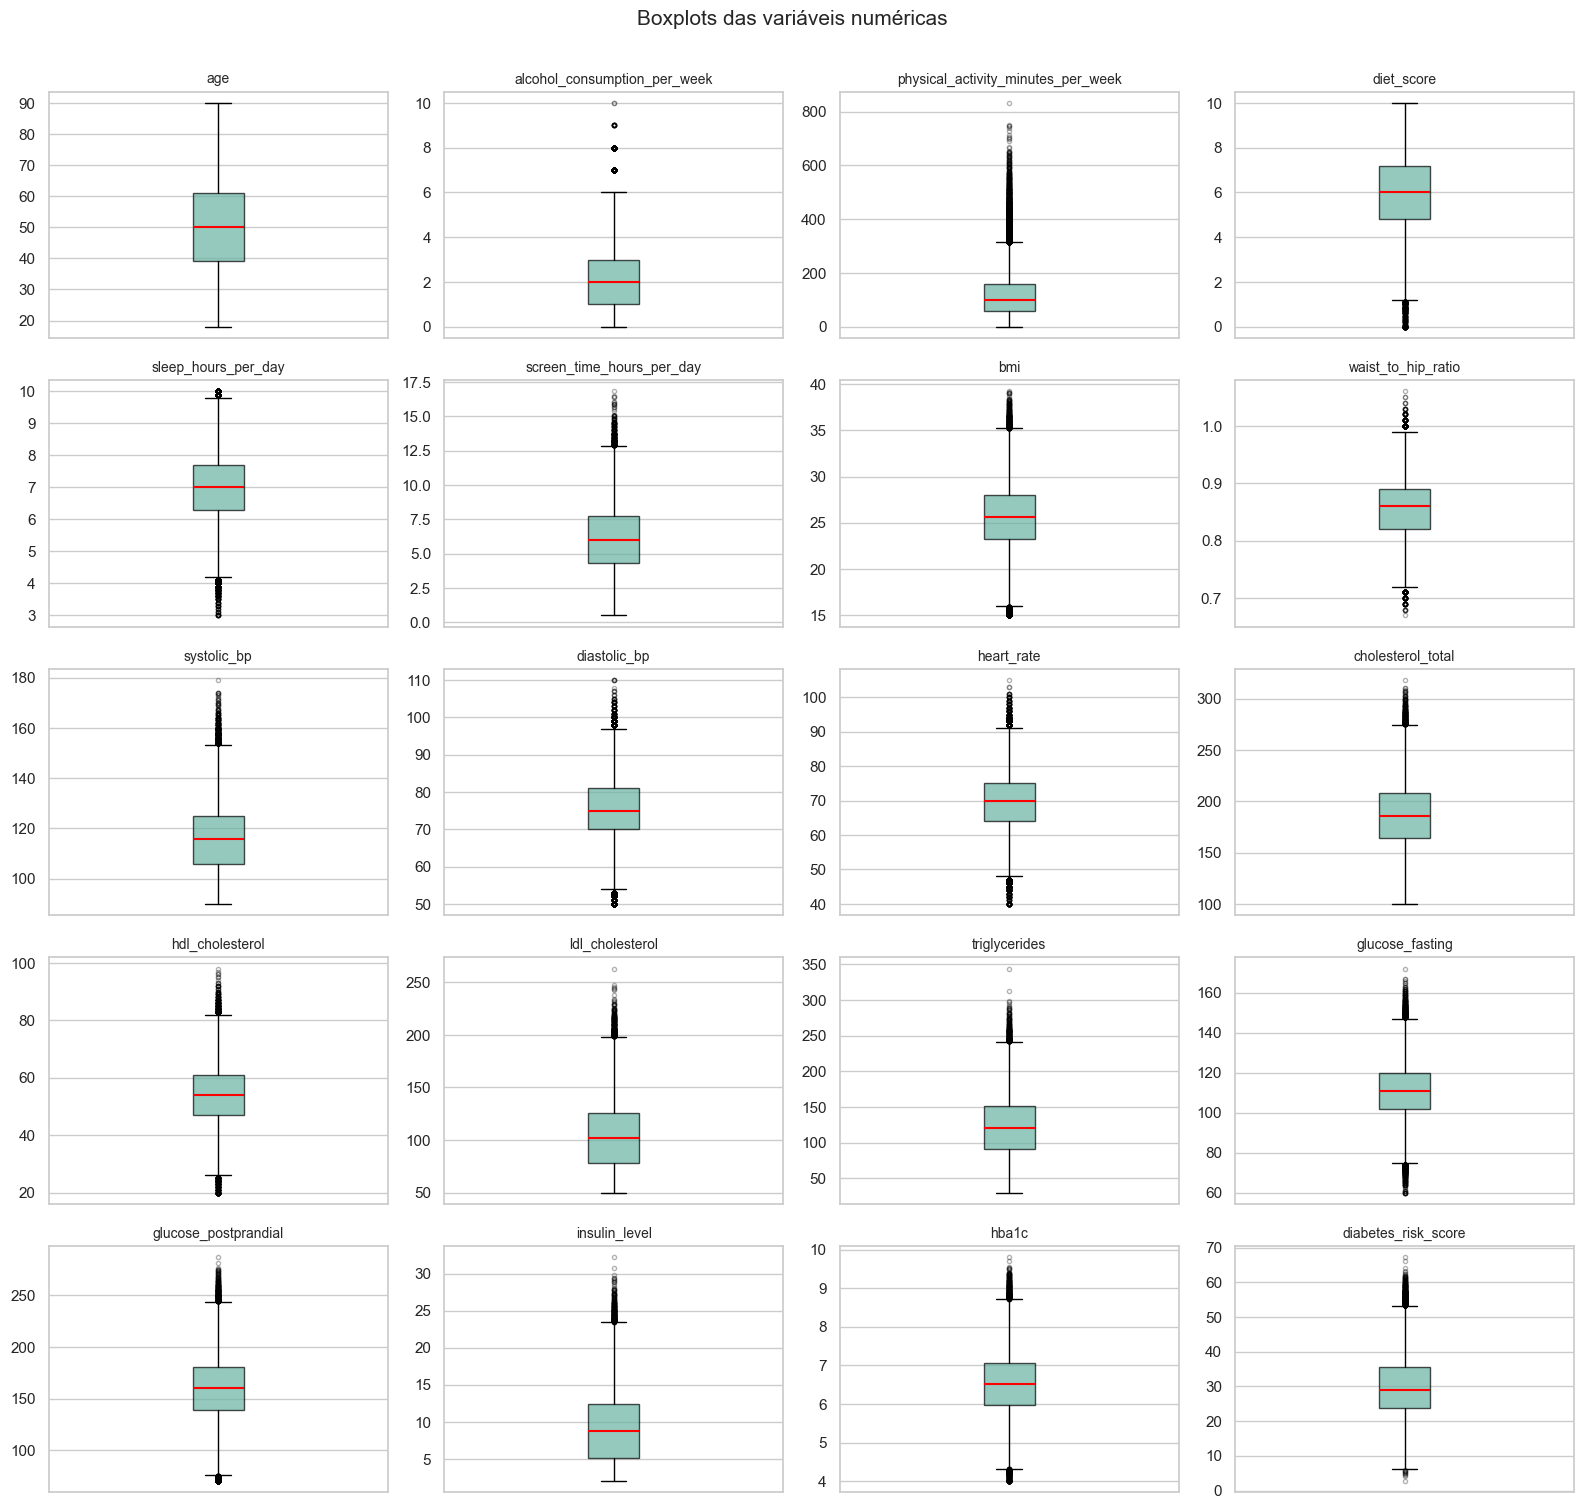

In [11]:
n = len(num_real)
ncols = 4
nrows = -(-n // ncols)   

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.ravel()

for ax, col in zip(axes, num_real):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#69b3a2", alpha=0.7),
               medianprops=dict(color="red", linewidth=1.5),
               flierprops=dict(marker="o", markersize=3, alpha=0.3))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])

# Esconde eixos que sobraram
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Boxplots das variáveis numéricas", fontsize=15, y=1.005)
fig.tight_layout()
plt.show()

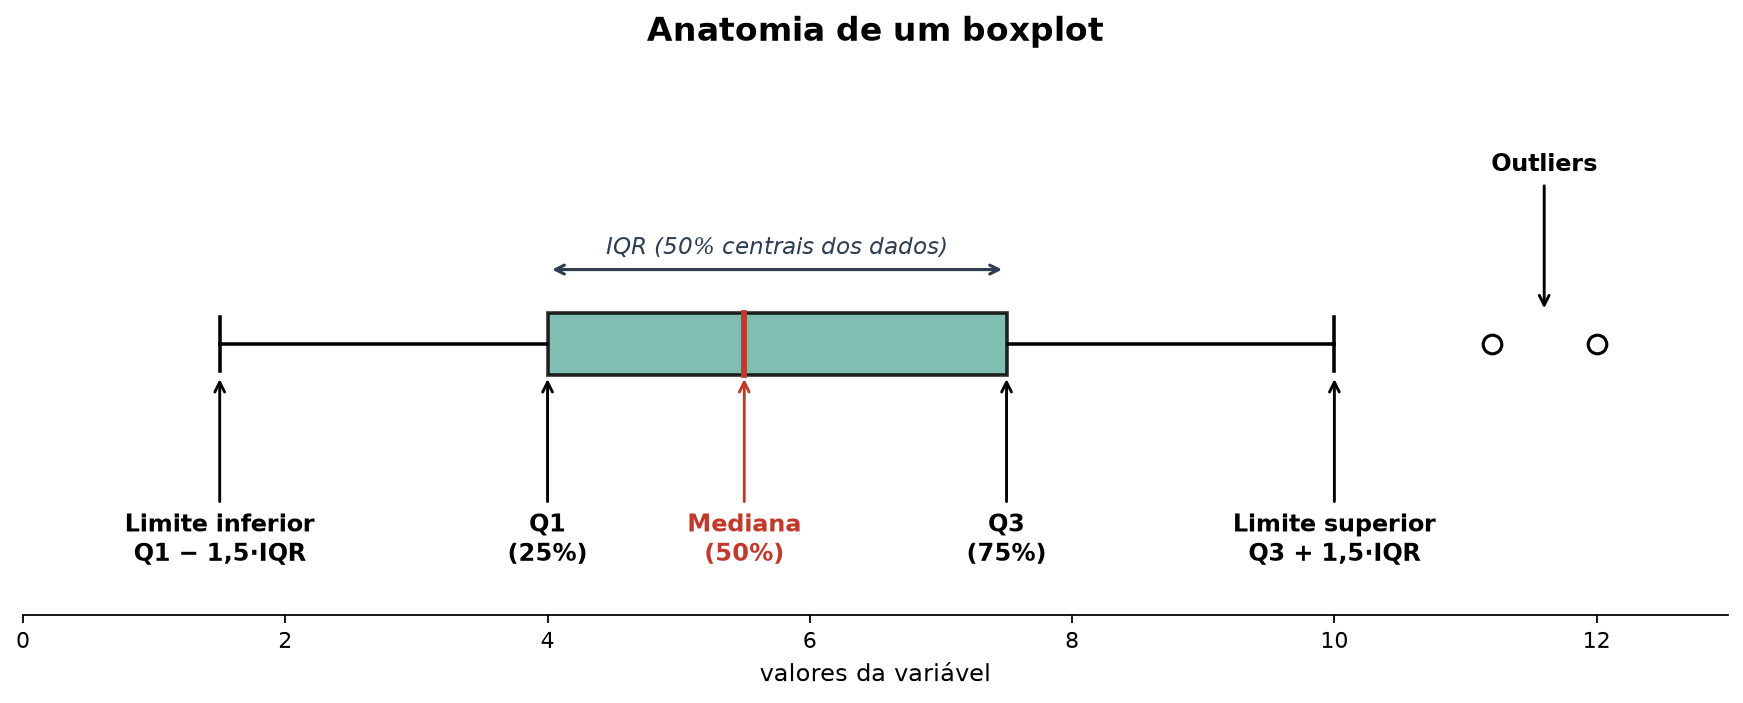


As plotagens simples de dispersão também podem ajudar a visualizar relações

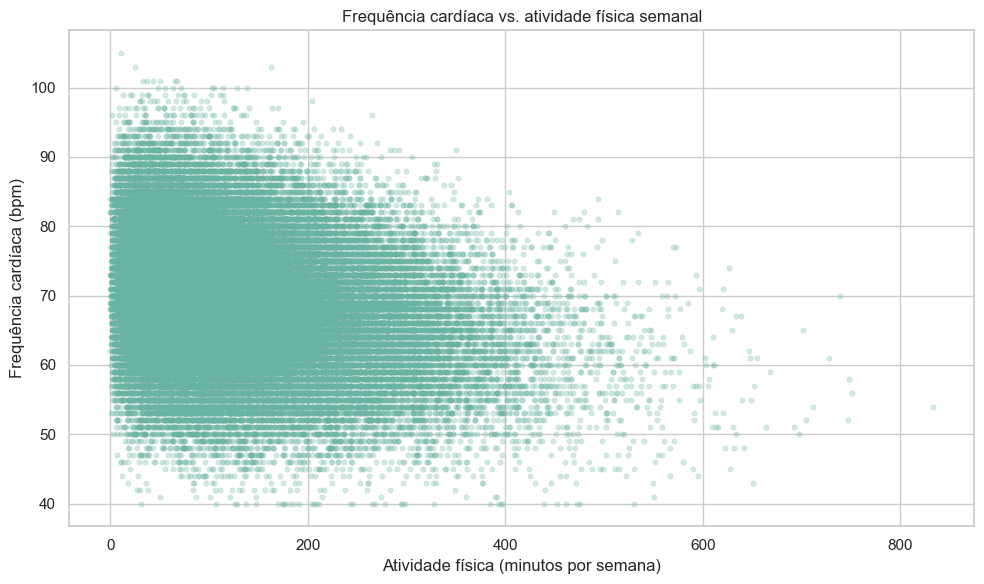

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="physical_activity_minutes_per_week", y="heart_rate",
                alpha=0.3, color="#69b3a2", edgecolor=None, s=15)

plt.title("Frequência cardíaca vs. atividade física semanal")
plt.xlabel("Atividade física (minutos por semana)")
plt.ylabel("Frequência cardíaca (bpm)")
plt.tight_layout()
plt.show()

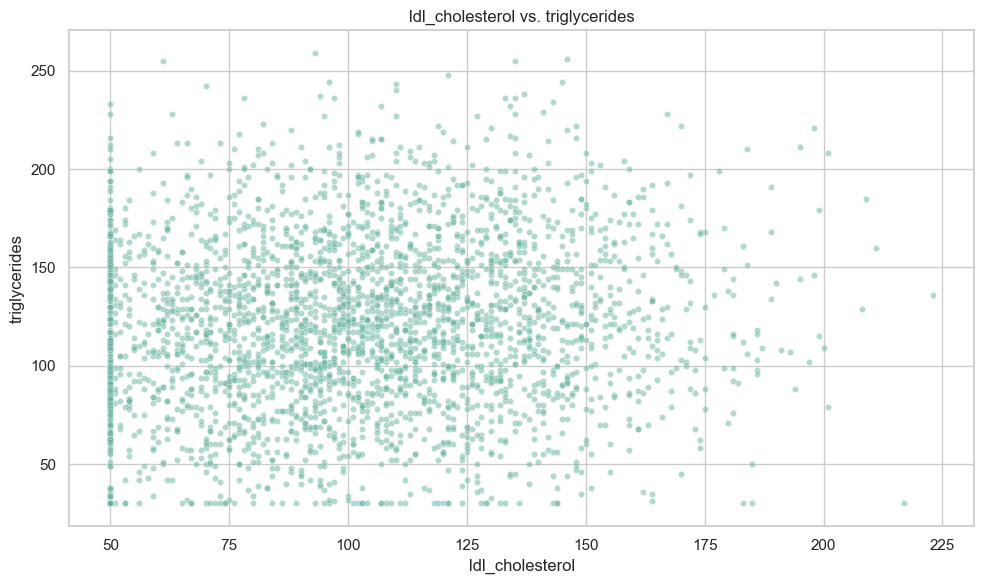

In [24]:
plt.figure(figsize=(10, 6))

eixo_x = "ldl_cholesterol"
eixo_y = "triglycerides"

sns.scatterplot(data=df.sample(3000, random_state=0),
                x=eixo_x, y=eixo_y,
                alpha=0.5, color="#69b3a2", s=20)

plt.title(f"{eixo_x} vs. {eixo_y}")
plt.xlabel(f"{eixo_x}")
plt.ylabel(f"{eixo_y}")
plt.tight_layout()
plt.show()

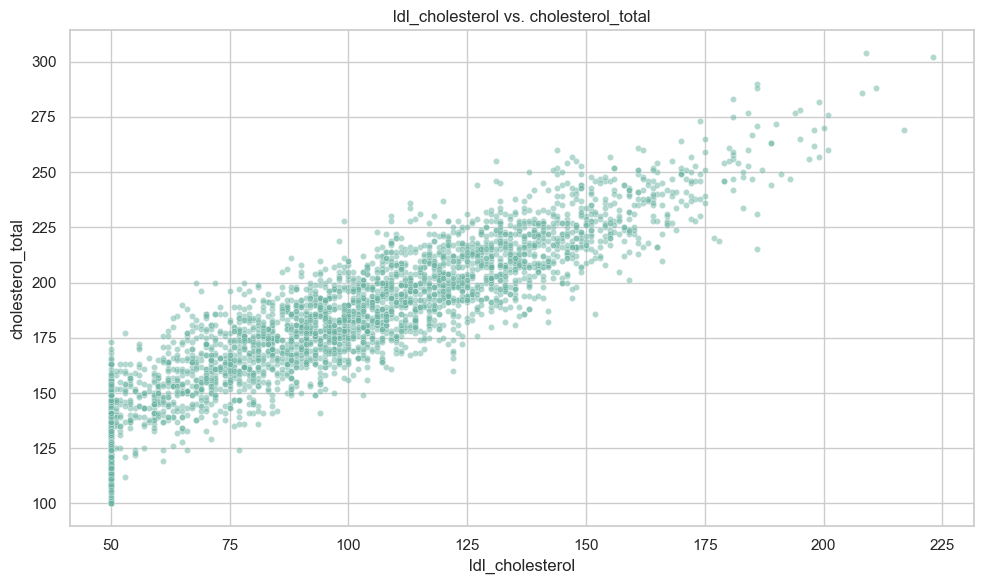

In [28]:
plt.figure(figsize=(10, 6))

eixo_x = "ldl_cholesterol"
eixo_y = "cholesterol_total"

sns.scatterplot(data=df.sample(3000, random_state=0),
                x=eixo_x, y=eixo_y,
                alpha=0.5, color="#69b3a2", s=20)

plt.title(f"{eixo_x} vs. {eixo_y}")
plt.xlabel(f"{eixo_x}")
plt.ylabel(f"{eixo_y}")
plt.tight_layout()
plt.show()

---

## 5 Medidas básicas de estatística: Média x Mediana x Moda

O conceito que é importante para discernir entre as médias e a presença e a intensidade dos outliers, que basicamente são "pontos fora da curva", e como lidamos com eles ditam muita coisa de como será a nossa

**Média**: É a simples soma de todos os valores dividido pela quantidade de valores

**Mediana**: É o elemento do "meio" em uma ordenação, ou seja, metade da base é menor ou igual e a outra metade é maior ou igual.

**Moda**: É o elemento que mais aparece.

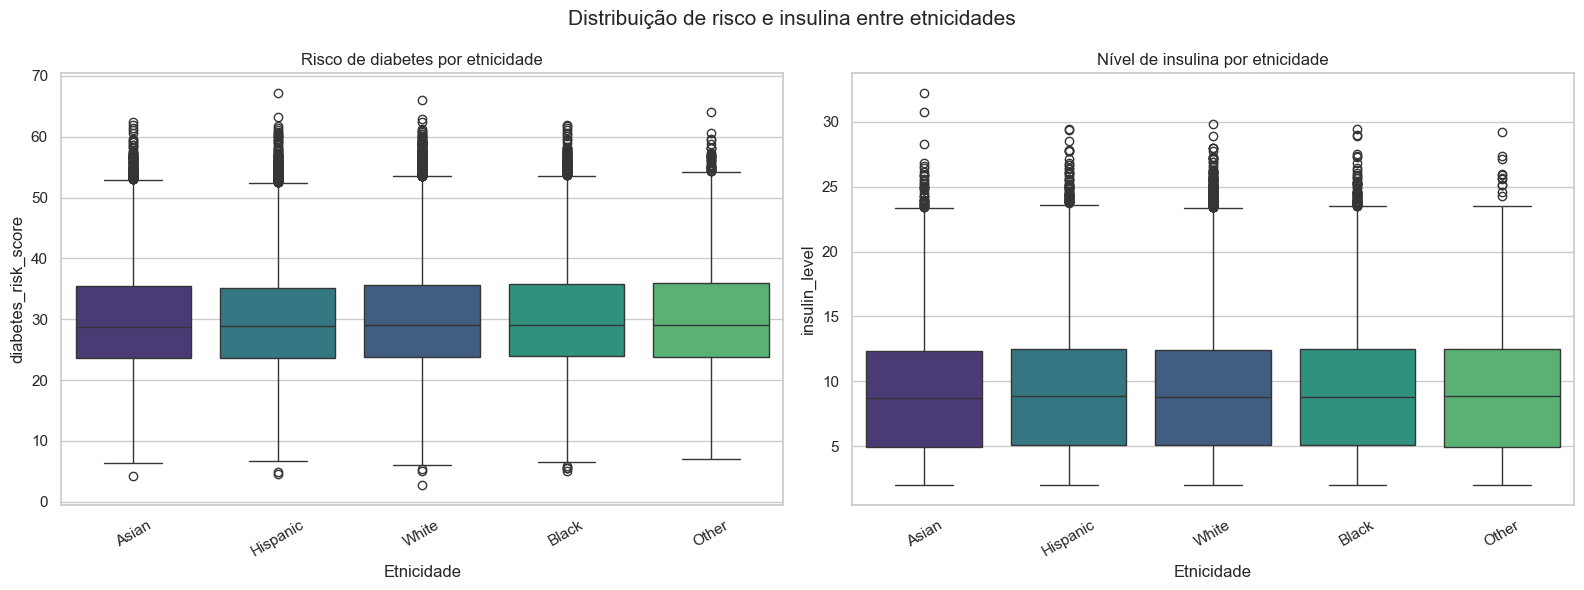

In [12]:
ordem = (df.groupby("ethnicity")["diabetes_risk_score"]
           .median().sort_values().index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Boxplot 1: risco de diabetes por etnicidade -------------------------
sns.boxplot(data=df, x="ethnicity", y="diabetes_risk_score",
            order=ordem, hue="ethnicity", legend=False, ax=axes[0])
axes[0].set_title("Risco de diabetes por etnicidade")
axes[0].set_xlabel("Etnicidade")
axes[0].set_ylabel("diabetes_risk_score")
axes[0].tick_params(axis="x", rotation=30)

# --- Boxplot 2: nível de insulina por etnicidade -------------------------
sns.boxplot(data=df, x="ethnicity", y="insulin_level",
            order=ordem, hue="ethnicity", legend=False, ax=axes[1])
axes[1].set_title("Nível de insulina por etnicidade")
axes[1].set_xlabel("Etnicidade")
axes[1].set_ylabel("insulin_level")
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Distribuição de risco e insulina entre etnicidades", fontsize=15)
fig.tight_layout()
plt.show()

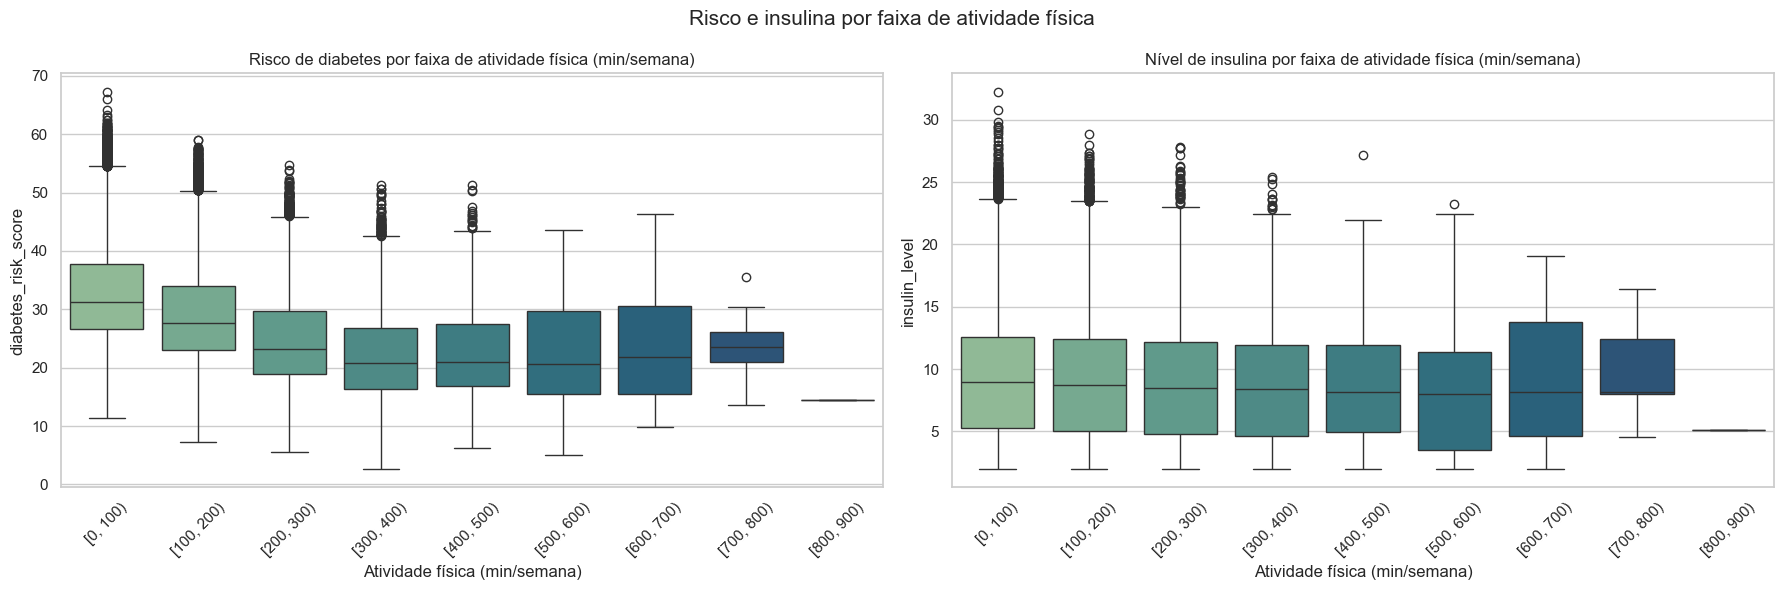

In [13]:
# Cria faixas regulares de largura 100 (0-100, 100-200, 200-300, ...)
col = "physical_activity_minutes_per_week"
limite = int(np.ceil(df[col].max() / 100) * 100)      # arredonda o topo p/ múltiplo de 100
bins = np.arange(0, limite + 100, 100)                 # bordas: 0, 100, 200, ...
df["faixa_atividade"] = pd.cut(df[col], bins=bins, right=False)  # [0,100), [100,200), ...

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Boxplot 1: risco de diabetes por faixa de atividade física ----------
sns.boxplot(data=df, x="faixa_atividade", y="diabetes_risk_score",
            hue="faixa_atividade", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Risco de diabetes por faixa de atividade física (min/semana)")
axes[0].set_xlabel("Atividade física (min/semana)")
axes[0].set_ylabel("diabetes_risk_score")
axes[0].tick_params(axis="x", rotation=45)

# --- Boxplot 2: nível de insulina por faixa de atividade física ----------
sns.boxplot(data=df, x="faixa_atividade", y="insulin_level",
            hue="faixa_atividade", legend=False, palette="crest", ax=axes[1])
axes[1].set_title("Nível de insulina por faixa de atividade física (min/semana)")
axes[1].set_xlabel("Atividade física (min/semana)")
axes[1].set_ylabel("insulin_level")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Risco e insulina por faixa de atividade física", fontsize=15)
fig.tight_layout()
plt.show()

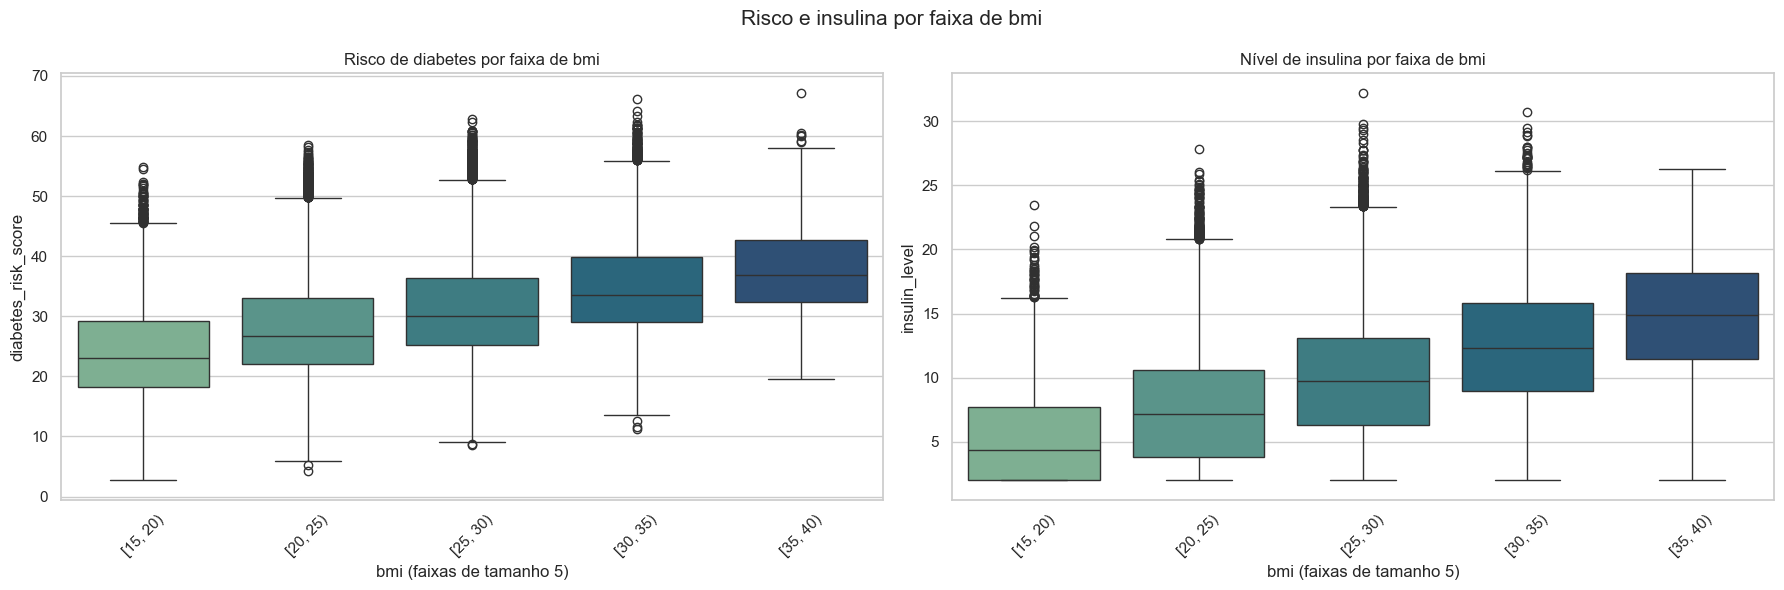

In [14]:
# Cria faixas regulares de largura 1 a partir do bmi
col = "bmi"
inicio = int(np.floor(df[col].min()))                 # piso arredondado p/ inteiro
fim    = int(np.ceil(df[col].max()))                  # teto arredondado p/ inteiro
bins   = np.arange(inicio, fim + 5, 5)                 # bordas: ..., 3, 4, 5, ...
df["faixa_dieta"] = pd.cut(df[col], bins=bins, right=False)  # [3,4), [4,5), ...

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Boxplot 1: risco de diabetes por faixa de bmi ----------------
sns.boxplot(data=df, x="faixa_dieta", y="diabetes_risk_score",
            hue="faixa_dieta", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Risco de diabetes por faixa de bmi")
axes[0].set_xlabel("bmi (faixas de tamanho 5)")
axes[0].set_ylabel("diabetes_risk_score")
axes[0].tick_params(axis="x", rotation=45)

# --- Boxplot 2: nível de insulina por faixa de bmi ----------------
sns.boxplot(data=df, x="faixa_dieta", y="insulin_level",
            hue="faixa_dieta", legend=False, palette="crest", ax=axes[1])
axes[1].set_title("Nível de insulina por faixa de bmi")
axes[1].set_xlabel("bmi (faixas de tamanho 5)")
axes[1].set_ylabel("insulin_level")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Risco e insulina por faixa de bmi", fontsize=15)
fig.tight_layout()
plt.show()

Tudo isso usando apenas box plots e métricas estatísticas básicas

---

## 6. Valores Faltantes e Outliers

In [18]:
# Sobre dados faltantes: técnicas básicas para remover nulos ou fazer imputação básica.
# OBS: este dataset é sintético e NÃO tem nulos, então as imputações abaixo são
# apenas ILUSTRATIVAS. Trabalhamos numa cópia (df_demo) para não afetar o df original.

df_demo = df.copy()

# --- Remoção de linhas/colunas ------------------------------------------------
df_demo = df_demo.dropna()                          # remove qualquer linha com ao menos 1 nulo
df_demo = df_demo.dropna(subset=["hba1c", "bmi"])   # só remove se faltar NESSAS colunas

# drop seguro: errors="ignore" evita KeyError se a coluna não existir
df_demo = df_demo.drop(columns=["coluna_com_60pct_nulos"], errors="ignore")

# --- Imputação por medida de tendência central --------------------------------
# Numérica simétrica → MÉDIA
df_demo["bmi"] = df_demo["bmi"].fillna(df_demo["bmi"].mean())

# Numérica assimétrica/com outliers → MEDIANA (mais robusta)
df_demo["triglycerides"] = df_demo["triglycerides"].fillna(df_demo["triglycerides"].median())

# Categórica → MODA
df_demo["smoking_status"] = df_demo["smoking_status"].fillna(df_demo["smoking_status"].mode()[0])

# --- Imputação condicional (por grupo) ----------------------------------------
# Primeiro criamos a faixa etária que o groupby precisa:
df_demo["faixa_etaria"] = pd.cut(
    df_demo["age"],
    bins=[0, 30, 45, 60, 75, 120],
    labels=["<30", "30-45", "45-60", "60-75", "75+"],
    right=False,
)

# Preenche o BMI faltante com a mediana do BMI do mesmo gênero + faixa etária
df_demo["bmi"] = (
    df_demo.groupby(["gender", "faixa_etaria"], observed=True)["bmi"]
           .transform(lambda s: s.fillna(s.median()))
)

# Também é possível fazer imputação com modelos, mas exige bastante cuidado.
# E, sobre outliers, também há muitas técnicas e teoria relevante a respeito.

print("Célula executada sem erros. Nulos restantes em df_demo:", int(df_demo.isnull().sum().sum()))

Célula executada sem erros. Nulos restantes em df_demo: 0


---

## 7. Acerca de dados médicos

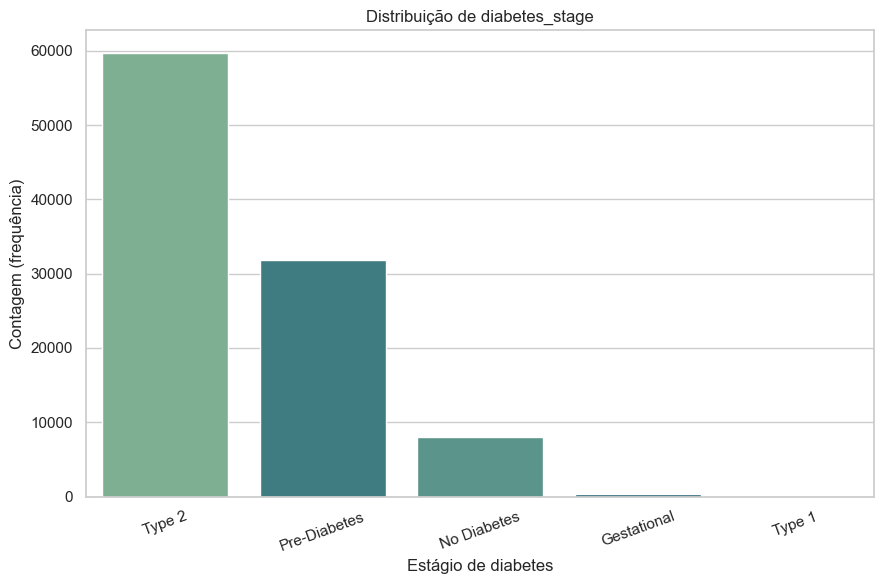

In [ ]:
plt.figure(figsize=(9, 6))

# Ordena as barras da mais frequente para a menos frequente
ordem = df["diabetes_stage"].value_counts().index

ax = sns.countplot(data=df, x="diabetes_stage", order=ordem,
                   hue="diabetes_stage", legend=False, palette="crest")

ax.set_title("Distribuição de diabetes_stage")
ax.set_xlabel("Estágio de diabetes")
ax.set_ylabel("Contagem (frequência)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Escala logarítmica

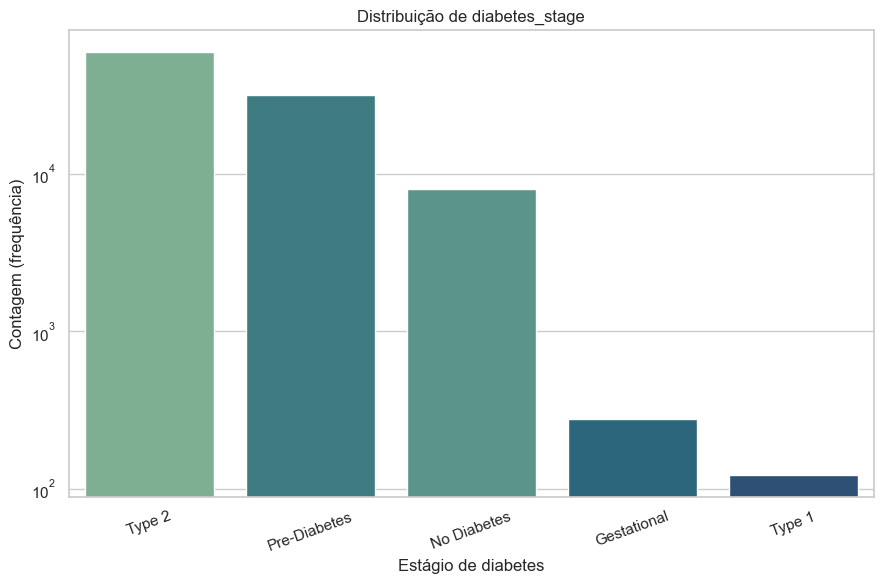

In [ ]:
plt.figure(figsize=(9, 6))

# Ordena as barras da mais frequente para a menos frequente
ordem = df["diabetes_stage"].value_counts().index

ax = sns.countplot(data=df, x="diabetes_stage", order=ordem,
                   hue="diabetes_stage", legend=False, palette="crest")


ax.set_title("Distribuição de diabetes_stage")
ax.set_xlabel("Estágio de diabetes")
ax.set_ylabel("Contagem (frequência)")
plt.xticks(rotation=20)
ax.set_yscale("log")
plt.tight_layout()
plt.show()  

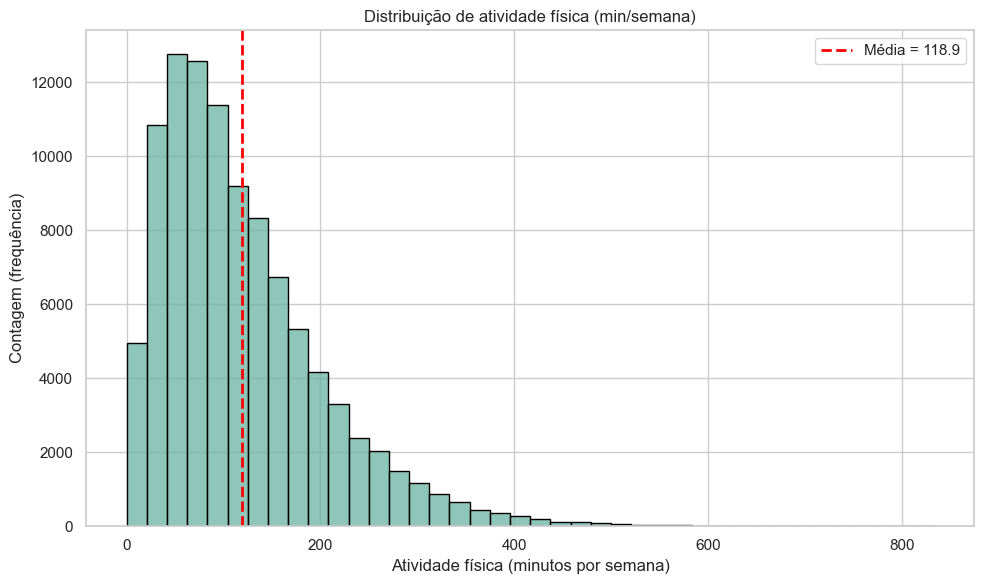

In [ ]:
plt.figure(figsize=(10, 6))

col = "physical_activity_minutes_per_week"
media = df[col].mean()

sns.histplot(data=df, x=col, bins=40, color="#69b3a2", edgecolor="black")

# Linha vermelha vertical na média
plt.axvline(media, color="red", linestyle="--", linewidth=2,
            label=f"Média = {media:.1f}")

plt.title("Distribuição de atividade física (min/semana)")
plt.xlabel("Atividade física (minutos por semana)")
plt.ylabel("Contagem (frequência)")
plt.legend()
plt.tight_layout()
plt.show()

## Primeira faixa de exercícios

A ideia daqui até o intervalo é aplicar esses tipos básicos de código para produzir mais visualizações. O objetivo desse tipo de análise no pipeline é descobrir coisas sobres os dados e formular hipóteses que serão testadas futuramente.

*Será que existe correlação entre faixa de salário e colesterol?*

*Será que existe correlação entre faixa de salário e nivel de educação?*




## 8. Teste de hipóteses: Fumantes

Primeiro uma ilustração, "Será que o status de fumante tem alguma relação com o risco de diabetes ou os níveis de insulina?"

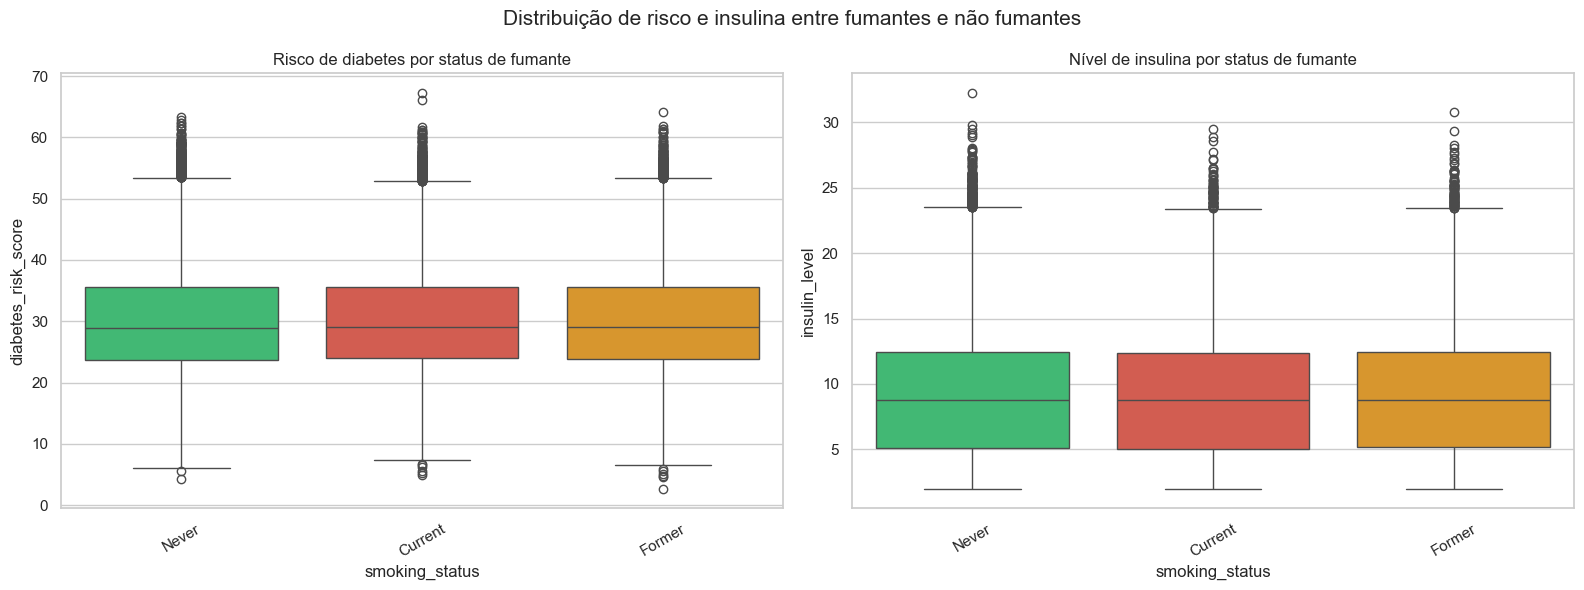

In [ ]:
cores = {
    "Never":   "#2ecc71",   # verde
    "Former":  "#f39c12",   # laranja
    "Current": "#e74c3c",   # vermelho
}

ordem = (df.groupby("smoking_status")["diabetes_risk_score"]
           .median().sort_values().index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Boxplot 1: risco de diabetes por status de fumante ------------------
sns.boxplot(data=df, x="smoking_status", y="diabetes_risk_score",
            order=ordem, hue="smoking_status", palette=cores,
            legend=False, ax=axes[0])
axes[0].set_title("Risco de diabetes por status de fumante")
axes[0].set_xlabel("smoking_status")
axes[0].set_ylabel("diabetes_risk_score")
axes[0].tick_params(axis="x", rotation=30)

# --- Boxplot 2: nível de insulina por status de fumante -----------------
sns.boxplot(data=df, x="smoking_status", y="insulin_level",
            order=ordem, hue="smoking_status", palette=cores,
            legend=False, ax=axes[1])
axes[1].set_title("Nível de insulina por status de fumante")
axes[1].set_xlabel("smoking_status")
axes[1].set_ylabel("insulin_level")
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Distribuição de risco e insulina entre fumantes e não fumantes", fontsize=15)
fig.tight_layout()
plt.show()

Então vamos para o teste de hipóteses, em geral temos sempre a hipótese nula de que a característica em questão não afeta em nada.

**Hipótese Nula: Status de fumante não tem relação com risco de diabetes**

**Hipótese Alternativa: Status de fumante tem relação com risco de diabetes**

Ou, em outras palavras: A hipótese alternativa é que a média de risco de diabetes entre os fumantes é diferente da média dos não fumantes.

Então temos a definição de valor-p: Considerando que nossa hipótese nula seja verdadeira, olhando para os dados que temos, qual é a probabilidade deles terem acontecido?

In [ ]:
from scipy import stats

# H0: as médias são iguais | H1: as médias são diferentes
grupo_fuma    = df[df["smoking_status"] == "Current"]["diabetes_risk_score"]
grupo_naofuma = df[df["smoking_status"] == "Never"]["diabetes_risk_score"]

t_stat, p_valor = stats.ttest_ind(grupo_fuma, grupo_naofuma, equal_var=False)

print(f"Estatística t: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.6f}")

alpha = 0.05
if p_valor <= alpha:
    print("→ Rejeitamos H0: a diferença é estatisticamente significativa.")
else:
    print("→ Não rejeitamos H0: sem evidência de diferença.")

Estatística t: 1.7944
Valor-p: 0.072764
→ Não rejeitamos H0: sem evidência de diferença.


## 9. Correlação

Até agora lidamos apenas com uma variável por vez nas estatísticas descritivas, e fizemos algumas plotagens entre duas variáveis que pode indicar uma relação entre elas, a partir de agora iremos trabalhar com métodos mais robustos de correlação.

A ideia básica da correlação é analisar quando variáveis crescem uma em relação a outra, se for positiva, crescem juntas, se for negativa, uma cresce quando a outra diminui, e se for próxima de 0 não é possível estabelecer essa relação.

A covariância é definida matematicamente entre variáveis numéricas. O problema com a covariância é que ela depende da escala das variáveis, isso faz com que ela não seja comparável entre diferentes pares, por isso normalmente utilizamos outras métricas.

In [ ]:
# Por isso normalmente usamos a correlação de Pearson 

df[num_cols].corr(method="pearson")            # matriz completa
df["glucose_fasting"].corr(df["hba1c"])         # par específico


0.7003515640407224

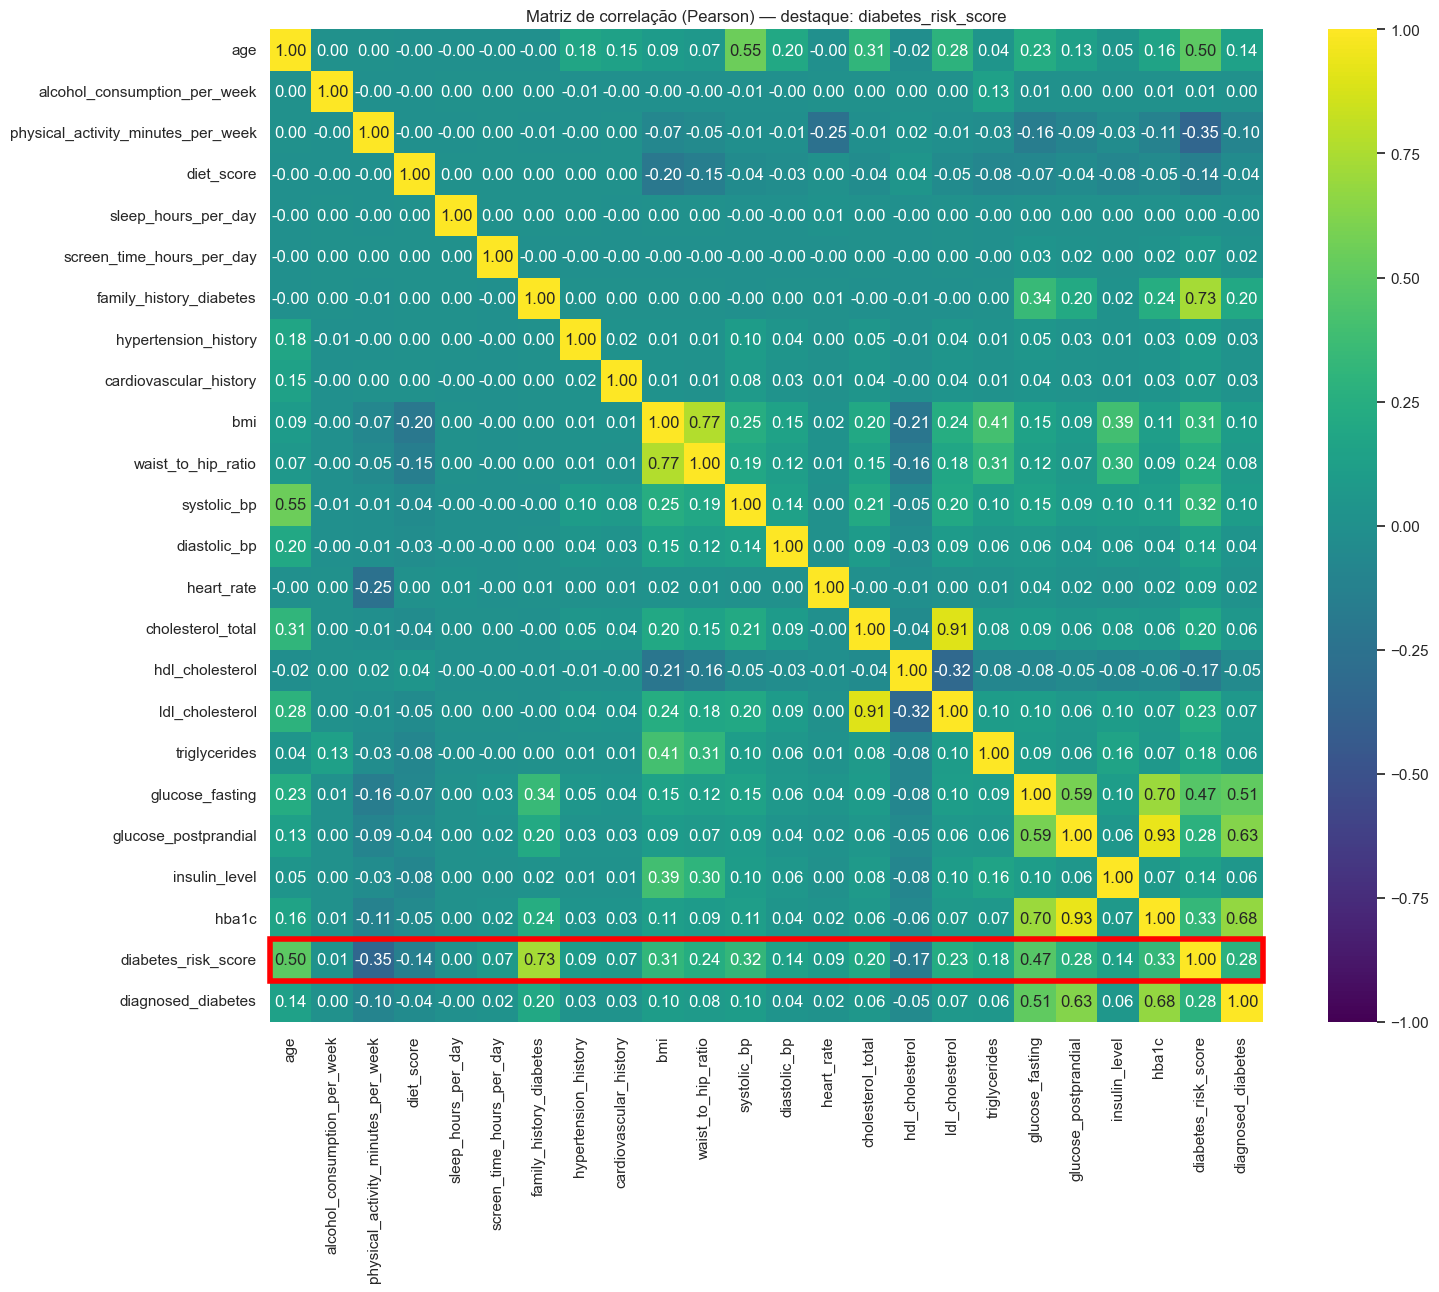

In [ ]:
from matplotlib.patches import Rectangle

corr = df[num_cols].corr(method="pearson")

plt.figure(figsize=(16, 13))
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis",
                 center=0, vmin=-1, vmax=1, square=True)

# --- Destaque na linha de diabetes_risk_score ---------------------------
alvo = "diabetes_risk_score"
i = corr.index.get_loc(alvo)          # posição (índice) da linha do alvo
n = corr.shape[1]                      # nº de colunas (largura da linha)

# Retângulo cobrindo a linha inteira, com borda vermelha grossa
ax.add_patch(Rectangle((0, i), n, 1, fill=False,
                        edgecolor="red", linewidth=4, clip_on=False))

plt.title("Matriz de correlação (Pearson) — destaque: diabetes_risk_score")
plt.tight_layout()
plt.show()



O teste depende do **tipo das variáveis** que você está comparando:

| Pergunta | Variáveis | Teste | Função (scipy) |
|---|---|---|---|
| Duas médias são diferentes? | numérica × categórica (2 grupos) | **t-test** | `stats.ttest_ind` |
| Duas categóricas estão associadas? | categórica × categórica | **Qui-quadrado** | `stats.chi2_contingency` |
| Duas variáveis numéricas se correlacionam? | numérica × numérica | **teste de correlação** | `stats.pearsonr` |

---

## 10. Ilustração básica de uma regressão linear

In [27]:
import statsmodels.api as sm

num_features = ["bmi", "glucose_fasting", "hba1c", "age",
                "physical_activity_minutes_per_week", "diet_score"]
cat_features = ["gender", "smoking_status", 'income_level']

# One-hot encoding; drop_first evita a "dummy trap" (multicolinearidade)
X = pd.get_dummies(df[num_features + cat_features],
                   columns=cat_features, drop_first=True, dtype=float)

y = df["diabetes_risk_score"]

X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                             OLS Regression Results                            
Dep. Variable:     diabetes_risk_score   R-squared:                       0.515
Model:                             OLS   Adj. R-squared:                  0.515
Method:                  Least Squares   F-statistic:                     7579.
Date:                 Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                         16:03:13   Log-Likelihood:            -3.2613e+05
No. Observations:               100000   AIC:                         6.523e+05
Df Residuals:                    99985   BIC:                         6.524e+05
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------